# Online Retail Growth Analysis

**Decision:** Which customer groups and markets should a small online retailer prioritize to grow repeat revenue, and what should it investigate about cancellation activity?

This notebook turns invoice-line records into sales, customer, cohort, and cancellation views. Results describe this retailer and this historical period; they are not causal estimates.

In [1]:
from pathlib import Path
import os
import sqlite3

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.environ['MPLCONFIGDIR'] = str(ROOT / '.cache' / 'matplotlib')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
DB = ROOT / 'data' / 'processed' / 'retail.db'
assert DB.exists(), 'Run python src/prepare_data.py first.'
con = sqlite3.connect(DB)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

## 1. Check the prepared data

Start with row counts, missing customer IDs, duplicates, and the date range. Keep cancellation and non-positive lines visible for data-quality context; filter them only when a business measure calls for it.

In [2]:
quality = pd.read_sql_query('''
SELECT COUNT(*) AS rows, COUNT(DISTINCT invoice_no) AS invoices,
       COUNT(DISTINCT customer_id) AS identified_customers,
       SUM(customer_id IS NULL) AS rows_without_customer_id,
       SUM(is_cancellation = 1) AS cancellation_lines,
       SUM(quantity <= 0) AS nonpositive_quantity_lines,
       SUM(unit_price <= 0) AS nonpositive_price_lines,
       MIN(invoice_date) AS first_date, MAX(invoice_date) AS last_date
FROM transactions''', con)
quality

,rows,invoices,identified_customers,rows_without_customer_id,cancellation_lines,nonpositive_quantity_lines,nonpositive_price_lines,first_date,last_date
0,1033036,53628,5942,235151,19104,22496,6019,2009-12-01 07:45:00,2011-12-09 12:50:00


## 2. Revenue and order trends

Revenue here is fulfilled positive line value in GBP. It excludes invoices marked as cancellations and lines with non-positive quantity or price.

In [3]:
monthly = pd.read_sql_query('''
SELECT strftime('%Y-%m', invoice_date) AS month,
       SUM(quantity * unit_price) AS sales_gbp,
       COUNT(DISTINCT invoice_no) AS invoices,
       COUNT(DISTINCT customer_id) AS identified_customers
FROM transactions WHERE is_cancellation = 0 AND quantity > 0 AND unit_price > 0
GROUP BY month ORDER BY month''', con, parse_dates=['month'])
monthly.tail()

,month,sales_gbp,invoices,identified_customers
20,2011-08-01,757841.380,1361,935
21,2011-09-01,1056435.192,1837,1266
22,2011-10-01,1151263.730,2040,1364
23,2011-11-01,1503866.780,2769,1664
24,2011-12-01,637808.330,819,615


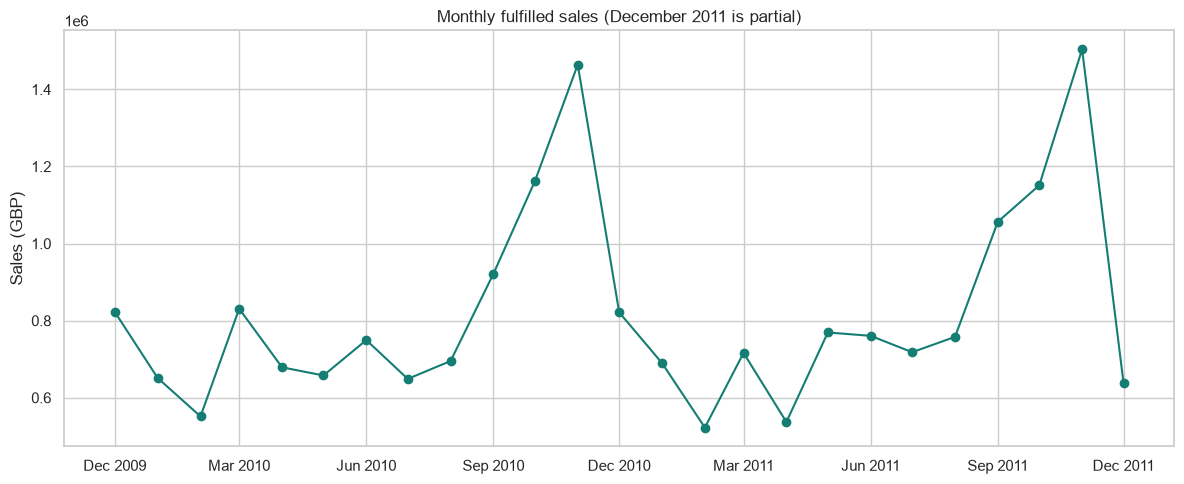

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month'], monthly['sales_gbp'], marker='o', color='#147D74')
ax.set(title='Monthly fulfilled sales (December 2011 is partial)', xlabel='', ylabel='Sales (GBP)')
tick_positions = list(range(0, len(monthly), 3))
if len(monthly) - 1 not in tick_positions:
    tick_positions.append(len(monthly) - 1)
ax.set_xticks(monthly['month'].iloc[tick_positions])
ax.set_xticklabels([d.strftime('%b %Y') for d in monthly['month'].iloc[tick_positions]], rotation=0)
fig.tight_layout()

Compare January–November in 2010 and 2011 so both periods contain the same complete months. Invoice value is the eligible positive line total within each non-cancellation invoice. December 2011 is incomplete in the source.

In [5]:
invoice_values = pd.read_sql_query('''
WITH invoice_totals AS (
  SELECT strftime('%Y', invoice_date) AS year, invoice_no,
         SUM(quantity * unit_price) AS invoice_value_gbp
  FROM transactions
  WHERE is_cancellation = 0 AND quantity > 0 AND unit_price > 0
    AND strftime('%m', invoice_date) BETWEEN '01' AND '11'
  GROUP BY year, invoice_no
)
SELECT * FROM invoice_totals ORDER BY year''', con)
year_comparison = invoice_values.groupby('year').agg(
    invoices=('invoice_no', 'nunique'),
    sales_gbp=('invoice_value_gbp', 'sum'),
    mean_invoice_gbp=('invoice_value_gbp', 'mean'),
    median_invoice_gbp=('invoice_value_gbp', 'median'),
).round(2)
year_comparison

,invoices,sales_gbp,mean_invoice_gbp,median_invoice_gbp
year,,,,
2010,18435,9011647.69,488.83,301.14
2011,17582,9182867.74,522.29,305.18


## 3. Repeat purchasing and cohorts

An identified customer counts as repeat when they have at least two distinct eligible sales invoices. This is descriptive: the data cannot identify the reasons behind repeat purchasing.

December 2011 is partial in this source, so it is excluded from the cohort matrix; follow-up activity is shown through November 2011.

In [6]:
invoices = pd.read_sql_query('''
SELECT customer_id, invoice_no, MIN(invoice_date) AS invoice_date,
       SUM(quantity * unit_price) AS invoice_value_gbp
FROM transactions WHERE customer_id IS NOT NULL AND is_cancellation = 0
  AND quantity > 0 AND unit_price > 0
GROUP BY customer_id, invoice_no''', con, parse_dates=['invoice_date'])
customer_invoices = invoices.groupby('customer_id').agg(
    invoices=('invoice_no', 'nunique'), first_invoice=('invoice_date', 'min'),
    last_invoice=('invoice_date', 'max'), revenue_gbp=('invoice_value_gbp', 'sum'))
repeat_summary = pd.Series({
    'identified_customers': len(customer_invoices),
    'repeat_customers': int((customer_invoices['invoices'] >= 2).sum()),
    'repeat_customer_share': float((customer_invoices['invoices'] >= 2).mean()),
    'median_invoices_per_customer': float(customer_invoices['invoices'].median()),
})
repeat_summary

identified_customers            5878.000000
repeat_customers                4255.000000
repeat_customer_share              0.723886
median_invoices_per_customer       3.000000
dtype: float64

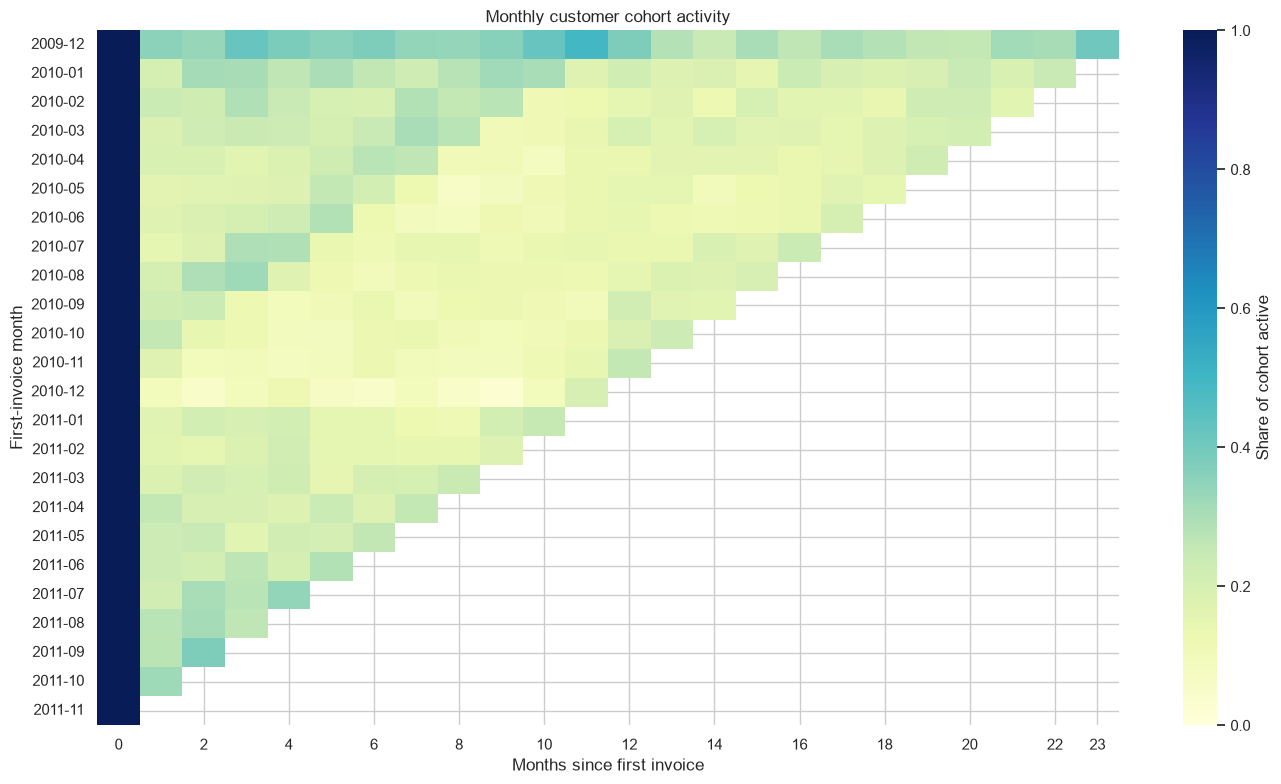

In [7]:
invoices['cohort_month'] = invoices.groupby('customer_id')['invoice_date'].transform('min').dt.to_period('M')
invoices['invoice_month'] = invoices['invoice_date'].dt.to_period('M')
cohort_source = invoices.loc[invoices['invoice_month'] < pd.Period('2011-12', freq='M')].copy()
cohort_source['cohort_age_months'] = (cohort_source['invoice_month'].dt.year - cohort_source['cohort_month'].dt.year) * 12 + (cohort_source['invoice_month'].dt.month - cohort_source['cohort_month'].dt.month)
cohort = cohort_source.groupby(['cohort_month', 'cohort_age_months'])['customer_id'].nunique().unstack(fill_value=0)
last_complete_month = cohort_source['invoice_month'].max()
cohort = cohort.reindex(columns=range(int(cohort.columns.max()) + 1), fill_value=0).astype(float)
for cohort_month in cohort.index:
    last_age = (last_complete_month.year - cohort_month.year) * 12 + last_complete_month.month - cohort_month.month
    cohort.loc[cohort_month, cohort.columns > last_age] = float('nan')
retention = cohort.div(cohort[0], axis=0)
plt.figure(figsize=(14, 8))
ax = sns.heatmap(retention, cmap='YlGnBu', vmin=0, vmax=1, mask=retention.isna(), cbar_kws={'label': 'Share of cohort active'})
cohort_ticks = list(range(0, len(retention.columns), 2))
if len(retention.columns) - 1 not in cohort_ticks:
    cohort_ticks.append(len(retention.columns) - 1)
ax.set_xticks([tick + 0.5 for tick in cohort_ticks])
ax.set_xticklabels(cohort_ticks, rotation=0)
plt.title('Monthly customer cohort activity')
plt.xlabel('Months since first invoice'); plt.ylabel('First-invoice month')
plt.tight_layout()

## 4. Customer value segments (RFM)

Rank identified customers by recency (days since their latest order), frequency (fulfilled invoices), and monetary value (fulfilled sales). The snapshot is the day after the final observed transaction. Segment shares use 5,878 customers with an ID and at least one eligible invoice. Quartiles are relative to this dataset; segment labels are prioritization heuristics, not predictions.

In [8]:
snapshot_date = invoices['invoice_date'].max().normalize() + pd.Timedelta(days=1)
rfm = invoices.groupby('customer_id').agg(
    last_purchase=('invoice_date', 'max'),
    frequency=('invoice_no', 'nunique'),
    monetary_gbp=('invoice_value_gbp', 'sum'),
).copy()
rfm['recency_days'] = (snapshot_date - rfm['last_purchase']).dt.days
rfm['R'] = pd.qcut(rfm['recency_days'].rank(method='first'), 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary_gbp'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['segment'] = 'Developing'
rfm.loc[(rfm.R >= 4) & (rfm.F >= 4) & (rfm.M >= 4), 'segment'] = 'Champions'
rfm.loc[(rfm.R >= 3) & (rfm.F >= 3) & (rfm.segment == 'Developing'), 'segment'] = 'Loyal'
rfm.loc[(rfm.R >= 4) & (rfm.F <= 2) & (rfm.segment == 'Developing'), 'segment'] = 'Recent, lower-frequency'
rfm.loc[(rfm.R <= 2) & (rfm.F >= 3), 'segment'] = 'At risk'
rfm.loc[(rfm.R <= 2) & (rfm.F <= 2), 'segment'] = 'Hibernating'
segment_summary = rfm.groupby('segment').agg(
    customers=('frequency', 'size'),
    revenue_gbp=('monetary_gbp', 'sum'),
    median_invoices=('frequency', 'median'),
    median_recency_days=('recency_days', 'median'),
).sort_values('revenue_gbp', ascending=False)
segment_summary['customer_share_pct'] = 100 * segment_summary['customers'] / len(rfm)
segment_summary['revenue_share_pct'] = 100 * segment_summary['revenue_gbp'] / rfm['monetary_gbp'].sum()
segment_summary.round(1)

C:\Users\DELL\AppData\Local\Temp\ipykernel_26844\1170539518.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  snapshot_date = invoices['invoice_date'].max().normalize() + pd.Timedelta(days=1)


,customers,revenue_gbp,median_invoices,median_recency_days,customer_share_pct,revenue_share_pct
segment,,,,,,
Champions,647,9325756.6,16.0,8.0,11.0,53.7
Loyal,1404,3985134.1,6.0,33.0,23.9,22.9
At risk,888,2183671.5,5.0,243.5,15.1,12.6
Hibernating,2051,1120227.0,1.0,408.0,34.9,6.4
Developing,566,386011.5,2.0,54.0,9.6,2.2
"Recent, lower-frequency",322,374003.7,2.0,12.0,5.5,2.2


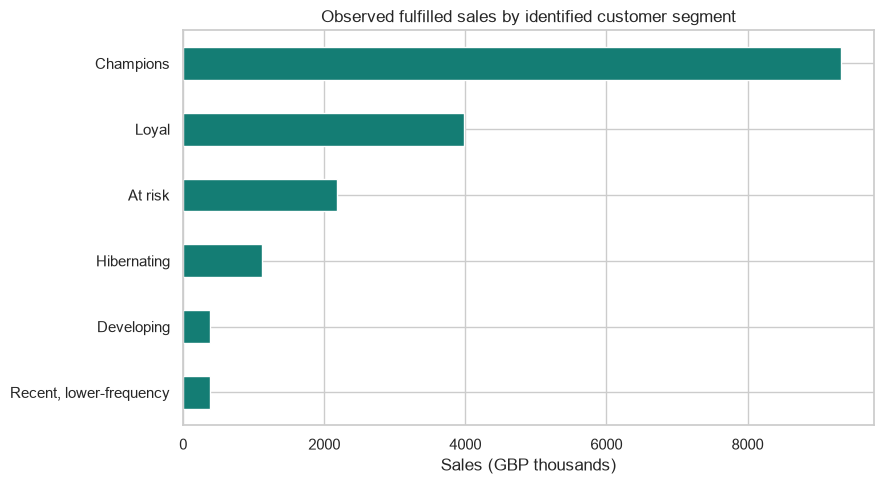

In [9]:
ax = segment_summary.sort_values('revenue_gbp')['revenue_gbp'].div(1000).plot.barh(
    figsize=(9, 5), color='#147D74')
ax.set(title='Observed fulfilled sales by identified customer segment', xlabel='Sales (GBP thousands)', ylabel='')
plt.tight_layout()

## 5. Geographic concentration

Compare countries on revenue and customer count. A high-revenue market may reflect a small number of high-value accounts, so look at both measures before proposing expansion.

In [10]:
countries = pd.read_sql_query('''
SELECT country, SUM(quantity * unit_price) AS sales_gbp,
       COUNT(DISTINCT invoice_no) AS invoices,
       COUNT(DISTINCT customer_id) AS identified_customers
FROM transactions WHERE is_cancellation = 0 AND quantity > 0 AND unit_price > 0
GROUP BY country ORDER BY sales_gbp DESC''', con)
countries.head(15)

,country,sales_gbp,invoices,identified_customers
0,United Kingdom,1.741020e+07,36535,5350
1,EIRE,6.587673e+05,626,5
2,Netherlands,5.540381e+05,228,22
3,Germany,4.250197e+05,789,107
4,France,3.504561e+05,622,95
5,Australia,1.692835e+05,95,15
6,Spain,1.083325e+05,154,41
7,Switzerland,1.006856e+05,93,22
8,Sweden,9.186982e+04,105,19
9,Denmark,6.858069e+04,43,12


## 6. Cancellation patterns

The monthly share of invoice IDs beginning with `C` is a diagnostic for cancellation or credit activity. It is not proof that a complete customer order failed. Cancellations are not netted against sales in this chart.

In [11]:
cancellations = pd.read_sql_query('''
SELECT strftime('%Y-%m', invoice_date) AS month,
       COUNT(DISTINCT CASE WHEN is_cancellation = 0 THEN invoice_no END) AS non_cancellation_invoices,
       COUNT(DISTINCT CASE WHEN is_cancellation = 1 THEN invoice_no END) AS cancellation_invoices,
       1.0 * COUNT(DISTINCT CASE WHEN is_cancellation = 1 THEN invoice_no END) /
         NULLIF(COUNT(DISTINCT invoice_no), 0) AS cancellation_share
FROM transactions GROUP BY month ORDER BY month''', con)
cancellations.tail()

,month,non_cancellation_invoices,cancellation_invoices,cancellation_share
20,2011-08,1459,278,0.160046
21,2011-09,1994,333,0.143103
22,2011-10,2275,362,0.137277
23,2011-11,3021,441,0.127383
24,2011-12,869,146,0.143842


## 7. Recommendations and next checks

### Evidence-backed findings

- **Sales and invoice volume diverged:** Jan–Nov sales rose 1.9% year over year (£9.01M to £9.18M), while non-cancellation invoice IDs fell 4.6% (18,435 to 17,582). Mean invoice value rose from £489 to £522; median rose from £301 to £305. These figures describe the change but do not establish its cause.
- **Identified repeat purchasing is common:** 4,255 of 5,878 customers (72.4%) had at least two eligible invoices.
- **Sales are concentrated among Champions:** 647 customers (11.0%) account for £9.33M (53.7%) of identified positive sales.
- **Customer analysis has a material coverage gap:** 235,151 rows (22.8%) have no customer ID and account for £3.10M (15.1%) in positive sales.
- **Cancellation markers need reconciliation:** 8,292 of 53,628 invoice IDs (15.5%) begin with `C`; this does not establish that whole orders were cancelled.

### Actions to test

1. Test a retention treatment among Champions against a holdout; measure incremental repeat-invoice rate and contribution margin.
2. Test reactivation among the 888-customer At risk segment against a randomized holdout. Its £2.18M is historical sales, not expected recovery.
3. Investigate where customer IDs are lost and improve capture while preserving anonymous transactions in overall sales reporting.
4. Reconcile a sample of `C` invoice IDs to determine whether they indicate full cancellation, partial reversal, return, or another credit event.

**Limitation:** This is observational data from one retailer (2009–2011). It supports prioritization hypotheses, not causal conclusions or current-market forecasts. Sales are gross positive line value, not margin.